In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import dill

In [160]:
dill.dump_session('session.pkl')

In [3]:
dill.load_session('session.pkl')

In [2]:
df_2022 = pd.read_csv('./csv/version3/2022_final.csv')
df_2023 = pd.read_csv('./csv/version3/2023_final.csv')
df_2024 = pd.read_csv('./csv/version3/2024_final.csv')

In [3]:
df_2022['year'] = 2022
df_2022

,id,name,kucbt_score,program,first_name,gender,year
0,KUCBT_2022_1,Susmita Rai,576,BE in Computer Engineering,susmita,f,2022
1,KUCBT_2022_6,Dipak Kumar Sah,729,BE in Computer Engineering,dipak,m,2022
2,KUCBT_2022_8,Swechchha Parajuli,539,BE in Computer Engineering,swechchha,f,2022
3,KUCBT_2022_9,Bhuwan Kshetri,592,BE in Civil Engineering (Specialization in Hyd...,bhuwan,m,2022
4,KUCBT_2022_11,Siddhartha Jha,580,BE in Civil Engineering (Specialization in Hyd...,siddhartha,m,2022
...,...,...,...,...,...,...,...
1660,KUCBT_2022_3258,Saan Sainju,532,BArch in Architecture,saan,m,2022
1661,KUCBT_2022_3259,Isha Lamichhane,714,BE in Mechanical Engineering(Automobile),isha,f,2022
1662,KUCBT_2022_3263,Samikshya Ghimire,652,BE in Geomatics Engineering,samikshya,f,2022
1663,KUCBT_2022_3267,GANGA RAM YADAV,848,BE in Civil Engineering (Specialization in Hyd...,ganga,f,2022


In [4]:
df_2023['year'] = 2023
df_2023['program'].value_counts()

program
BE in Computer Engineering                                     1248
BE in Civil Engineering (Specialization in Hydropower)          456
BArch in Architecture                                           187
BTech in Artificial Intelligence                                 81
BE in Geomatics Engineering                                      75
BE in Electrical & Electronic Engineering (Power & Control)      49
BE in Mechanical Engineering(Design and Manufacturing)           43
BE in Mechanical Engineering(Automobile)                         41
BE in Electrical & Electronic Engineering (Communicaon)          37
BE in Mechanical Engineering(Energy Technology)                  16
BE in Mechanical Engineering(Hydropower)                         14
BE in Mining Engineering                                          8
BE in Chemical Engineering                                        8
Name: count, dtype: int64

In [7]:
df_2024['year'] = 2024
df_2024

,id,name,kucbt_score,program,first_name,gender,year
0,KUSoE_2024_1,Aashutosh Singh,721,BE in Computer Engineering,aashutosh,m,2024
1,KUSoE_2024_2,PRANAY MALLIK,641,BE in Computer Engineering,pranay,m,2024
2,KUSoE_2024_3,SARJU SAHANI,709,BArch in Architecture,sarju,f,2024
3,KUSoE_2024_6,Ashmit Shah,721,BE in Electrical & Electronic Engineering (Com...,ashmit,m,2024
4,KUSoE_2024_7,Surasa Silpakar,873,BE in Computer Engineering,surasa,f,2024
...,...,...,...,...,...,...,...
1779,KUSoE_2024_2559,Bibek Pariyar,596,BE in Computer Engineering,bibek,m,2024
1780,KUSoE_2024_2561,Nabraj Sigdel,645,BE in Computer Engineering,nabraj,m,2024
1781,KUSoE_2024_2564,Simran Neupane,542,BE in Computer Engineering,simran,m,2024
1782,KUSoE_2024_2565,Swikar Kharal,760,BE in Computer Engineering,swikar,m,2024


In [8]:
df_2023['program'].value_counts()

program
BE in Computer Engineering                                     1248
BE in Civil Engineering (Specialization in Hydropower)          456
BArch in Architecture                                           187
BTech in Artificial Intelligence                                 81
BE in Geomatics Engineering                                      75
BE in Electrical & Electronic Engineering (Power & Control)      49
BE in Mechanical Engineering(Design and Manufacturing)           43
BE in Mechanical Engineering(Automobile)                         41
BE in Electrical & Electronic Engineering (Communication)        37
BE in Mechanical Engineering(Energy Technology)                  16
BE in Mechanical Engineering(Hydropower)                         14
BE in Mining Engineering                                          8
BE in Chemical Engineering                                        8
Name: count, dtype: int64

In [9]:
df_2022['program'].value_counts()

program
BE in Computer Engineering                                     770
BE in Civil Engineering (Specialization in Hydropower)         437
BArch in Architecture                                          177
BE in Geomatics Engineering                                     68
BE in Mechanical Engineering(Automobile)                        42
BE in Mechanical Engineering(Design and Manufacturing)          41
BTech in Artificial Intelligence                                40
BE in Electrical & Electronic Engineering (Power & Control)     40
BE in Electrical & Electronic Engineering (Communication)       29
BE in Chemical Engineering                                      11
BE in Mechanical Engineering(Hydropower)                         5
BE in Mechanical Engineering(Energy Technology)                  5
Name: count, dtype: int64

In [10]:
df_2024['program'].value_counts()

program
BE in Computer Engineering                                     1080
BE in Civil Engineering (Specialization in Hydropower)          287
BArch in Architecture                                           161
BE in Geomatics Engineering                                      68
BTech in Artificial Intelligence                                 62
BE in Mechanical Engineering(Automobile)                         32
BE in Mechanical Engineering(Design and Manufacturing)           28
BE in Electrical & Electronic Engineering (Power & Control)      28
BE in Electrical & Electronic Engineering (Communication)        26
BE in Mechanical Engineering(Energy Technology)                   5
BE in Mechanical Engineering(Hydropower)                          4
BE in Mining Engineering                                          3
Name: count, dtype: int64

In [11]:
df = pd.concat([df_2022, df_2023, df_2024])

In [13]:
df['program'].value_counts()

program
BE in Computer Engineering                                     3098
BE in Civil Engineering (Specialization in Hydropower)         1180
BArch in Architecture                                           525
BE in Geomatics Engineering                                     211
BTech in Artificial Intelligence                                183
BE in Electrical & Electronic Engineering (Power & Control)     117
BE in Mechanical Engineering(Automobile)                        115
BE in Mechanical Engineering(Design and Manufacturing)          112
BE in Electrical & Electronic Engineering (Communication)        92
BE in Mechanical Engineering(Energy Technology)                  26
BE in Mechanical Engineering(Hydropower)                         23
BE in Chemical Engineering                                       19
BE in Mining Engineering                                         11
Name: count, dtype: int64

In [14]:
# #Analysis begins:
# # Male-to-Female ratio

In [15]:
gender_proportion_2022 = df_2022['gender'].value_counts(normalize=True)
gender_proportion_2023 = df_2023['gender'].value_counts(normalize = True)
gender_proportion_2024 = df_2024['gender'].value_counts(normalize = True)

In [16]:
gender_proportion_2022

gender
m    0.706907
f    0.293093
Name: proportion, dtype: float64

In [17]:
gender_proportion_2023

gender
m    0.731772
f    0.268228
Name: proportion, dtype: float64

In [18]:
gender_proportion_2024

gender
m    0.717489
f    0.282511
Name: proportion, dtype: float64

In [19]:
# From a cursory glance, it seems that the ratio has remained consistently 7:3 for all the three years. To conclude
# this mathematically, we will perform a chi-squared test.

# The null hypothesis is that the gender ratio is indeed 7:3 for all three years (2022 = 2023 = 2024)
# The alternate hypothesis is that there is at least one year where the ratio does not hold up.
# Lets set the significance level to be 0.05

# Doing the chi-squared test, the p-value is calculated as 0.22 which is well above the threshold of 0.05. 
# Thus, there is not enough evidence to suggest that the proportion of gender is other than 7:3.

In [20]:
male_popn = [(df_2022['gender']=='m').sum(), (df_2023['gender']=='m').sum(), (df_2024['gender']=='m').sum()]
female_popn = [(df_2022['gender']=='f').sum(), (df_2023['gender']=='f').sum(), (df_2024['gender']=='f').sum()]

chi_data = pd.DataFrame({
    'Male': male_popn,
    'Female': female_popn
}, index = ['2022', '2023', '2024'])

chi2, p, dof, expected = chi2_contingency(chi_data)
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected counts:")
print(expected)

Chi-squared statistic: 3.0275128424698647
p-value: 0.22008170367467958
Degrees of freedom: 2
Expected counts:
[[1198.90493697  466.09506303]
 [1629.50262605  633.49737395]
 [1284.59243697  499.40756303]]


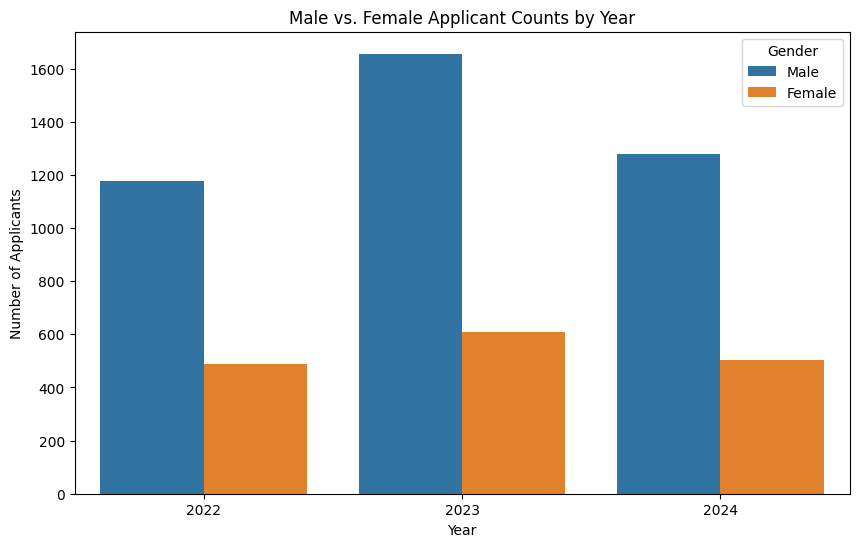

In [21]:
df_long = chi_data.reset_index().melt(id_vars='index', var_name='Gender', value_name='Count')
df_long.rename(columns={'index': 'Year'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_long, x='Year', y='Count', hue = 'Gender')

plt.title('Male vs. Female Applicant Counts by Year')
plt.xlabel('Year')
plt.ylabel('Number of Applicants')
plt.show()

In [22]:
#Coefficient of Variation

In [23]:
gender_ratio_2022 = gender_proportion_2022.iloc[0]/gender_proportion_2022.iloc[1]
gender_ratio_2023 = gender_proportion_2023.iloc[0]/gender_proportion_2023.iloc[1]
gender_ratio_2024 = gender_proportion_2024.iloc[0]/gender_proportion_2024.iloc[1]

gender_ratio = np.array([gender_ratio_2022, gender_ratio_2023, gender_ratio_2024])
cv1 = np.std(gender_ratio, ddof = 1) / np.mean(gender_ratio)
cv1*100

np.float64(6.215468241356241)

In [73]:
#90th percentile scorers:

#What is the average score of the top 10% scorers for all 3 years?
#What majors do the top 10% scorers chose in general?

In [71]:
q90_2022 = df_2022[df_2022['kucbt_score'] >= df_2022['kucbt_score'].quantile(0.90)]
q90_2023 = df_2023[df_2023['kucbt_score'] >= df_2023['kucbt_score'].quantile(0.90)]
q90_2024 = df_2024[df_2024['kucbt_score'] >= df_2024['kucbt_score'].quantile(0.90)]

q90_list = [
    q90_2022,
    q90_2023,
    q90_2024]

for record in q90_list:
    print(len(record))

167
228
180


In [ ]:
#Avg score of q90 for each of the years:

In [90]:
q90_avg_score_2022 = q90_2022.kucbt_score.mean()
q90_avg_score_2023 = q90_2023.kucbt_score.mean()
q90_avg_score_2024 = q90_2024.kucbt_score.mean()
q90_avg_score = [q90_avg_score_2022, q90_avg_score_2023, q90_avg_score_2024]

In [91]:
for score in q90_avg_score:
    print(score)

1037.2095808383233
1144.2412280701753
1176.0944444444444


In [95]:
q90_plot = pd.DataFrame({
    'Year': [2022, 2023, 2024],
    'Average score': q90_avg_score
})

q90_plot

,Year,Average score
0,2022,1037.209581
1,2023,1144.241228
2,2024,1176.094444


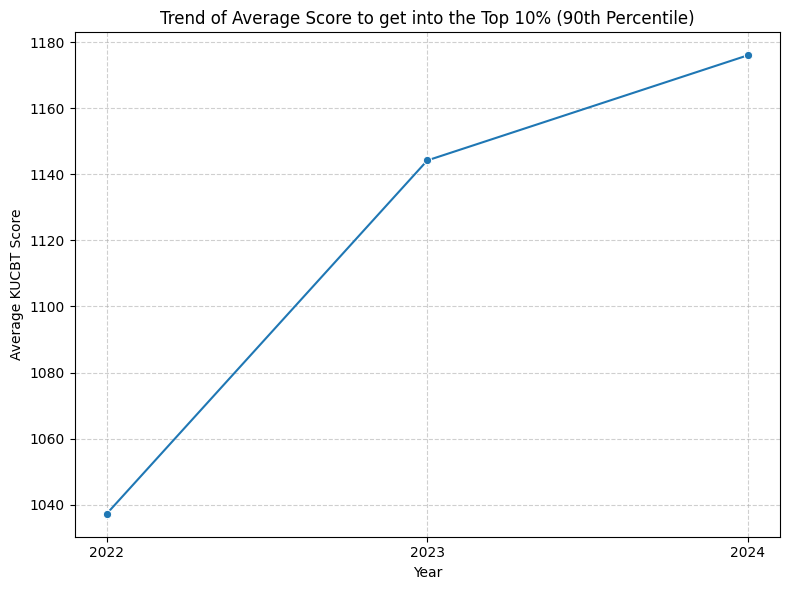

In [4]:
plt.figure(figsize = (8, 6))


ax2 = sns.lineplot(data = q90_plot, x = 'Year', y = 'Average score', marker = 'o')
plt.title('Trend of Average Score to get into the Top 10% (90th Percentile)')
plt.xticks([2022, 2023, 2024])
plt.xlabel('Year')
plt.ylabel('Average KUCBT Score')
plt.tight_layout()
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.show()

In [5]:
#Cutoff for each major

In [41]:
x = (q90_2022['program'].unique())

program_seats = {}

for program in x:
    if ('Computer') in program or ('Geomatics') in program or ('Civil') in program:
        program_seats[program] = 60
    else:
        program_seats[program] = 30
    
program_seats

{'BE in Civil Engineering (Specialization in Hydropower)': 60,
 'BE in Computer Engineering': 60,
 'BE in Chemical Engineering': 30,
 'BE in Electrical & Electronic Engineering (Communication)': 30,
 'BE in Electrical & Electronic Engineering (Power & Control)': 30,
 'BArch in Architecture': 30,
 'BE in Mechanical Engineering(Automobile)': 30,
 'BTech in Artificial Intelligence': 30,
 'BE in Mechanical Engineering(Design and Manufacturing)': 30,
 'BE in Geomatics Engineering': 60,
 'BE in Mechanical Engineering(Energy Technology)': 30}

In [69]:
    program_applicants = df_2022[df_2022['program'].str.contains('Computer')]
    len(program_applicants)

770

In [85]:
df_2023[df_2023['program'].str.contains('Computer')].sort_values(by = 'kucbt_score', ascending = False).iloc[58]

id                        KUCAT_2023_1129
name                      Nerish Shrestha
kucbt_score                          1155
program        BE in Computer Engineering
first_name                         nerish
gender                                  m
year                                 2023
Name: 862, dtype: object

In [74]:
cutoff_score_2022 = {}
cutoff_score_2023 = {}
cutoff_score_2024 = {}
MIN_PASS_SCORE = 528

for program, seat in program_seats.items():
    
    # --- Handle 2022 ---
    program_applicants_2022 = df_2022[df_2022['program'] == program]
    if len(program_applicants_2022) >= seat:
        cutoff_2022 = program_applicants_2022.sort_values(by='kucbt_score', ascending=False).iloc[seat-1]['kucbt_score']
        cutoff_score_2022[program] = int(cutoff_2022)
    else:
        cutoff_score_2022[program] = MIN_PASS_SCORE
        print(f"Warning for 2022: Program '{program}' had only {len(program_applicants_2022)} applicants for {seat} seats.")
        
    # --- Handle 2023 ---
    program_applicants_2023 = df_2023[df_2023['program'] == program]
    if len(program_applicants_2023) >= seat:
        cutoff_2023 = program_applicants_2023.sort_values(by='kucbt_score', ascending=False).iloc[seat-1]['kucbt_score']
        cutoff_score_2023[program] = int(cutoff_2023)
    else:
        cutoff_score_2023[program] = MIN_PASS_SCORE
        print(f"Warning for 2023: Program '{program}' had only {len(program_applicants_2023)} applicants for {seat} seats.")

    # --- Handle 2024 ---
    program_applicants_2024 = df_2024[df_2024['program'] == program]
    if len(program_applicants_2024) >= seat:
        cutoff_2024 = program_applicants_2024.sort_values(by='kucbt_score', ascending=False).iloc[seat-1]['kucbt_score']
        cutoff_score_2024[program] = int(cutoff_2024)
    else:
        cutoff_score_2024[program] = MIN_PASS_SCORE
        print(f"Warning for 2024: Program '{program}' had only {len(program_applicants_2024)} applicants for {seat} seats.")



Warning for 2022: Program 'BE in Chemical Engineering' had only 11 applicants for 30 seats.
Warning for 2023: Program 'BE in Chemical Engineering' had only 8 applicants for 30 seats.
Warning for 2024: Program 'BE in Chemical Engineering' had only 0 applicants for 30 seats.
Warning for 2022: Program 'BE in Electrical & Electronic Engineering (Communication)' had only 29 applicants for 30 seats.
Warning for 2024: Program 'BE in Electrical & Electronic Engineering (Communication)' had only 26 applicants for 30 seats.
Warning for 2024: Program 'BE in Electrical & Electronic Engineering (Power & Control)' had only 28 applicants for 30 seats.
Warning for 2024: Program 'BE in Mechanical Engineering(Design and Manufacturing)' had only 28 applicants for 30 seats.
Warning for 2022: Program 'BE in Mechanical Engineering(Energy Technology)' had only 5 applicants for 30 seats.
Warning for 2023: Program 'BE in Mechanical Engineering(Energy Technology)' had only 16 applicants for 30 seats.
Warning fo

In [78]:
cutoff_score_2023

{'BE in Civil Engineering (Specialization in Hydropower)': 934,
 'BE in Computer Engineering': 1153,
 'BE in Chemical Engineering': 528,
 'BE in Electrical & Electronic Engineering (Communication)': 631,
 'BE in Electrical & Electronic Engineering (Power & Control)': 713,
 'BArch in Architecture': 840,
 'BE in Mechanical Engineering(Automobile)': 621,
 'BTech in Artificial Intelligence': 726,
 'BE in Mechanical Engineering(Design and Manufacturing)': 672,
 'BE in Geomatics Engineering': 576,
 'BE in Mechanical Engineering(Energy Technology)': 528}

In [6]:
cutoff_score = []
for program, score in cutoff_score_2022.items():
    cutoff_score.append(
        {
            'Program':clean_names(program),
            'Score': score,
            'Year': 2022
        }
    )
    
for program, score in cutoff_score_2023.items():
    cutoff_score.append(
        {
            'Program':clean_names(program),
            'Score': score,
            'Year': 2023
        }
    )
    
for program, score in cutoff_score_2024.items():
    cutoff_score.append(
        {
            'Program':clean_names(program),
            'Score': score,
            'Year': 2024
        }
    )
    
cutoff_plot_data = pd.DataFrame(cutoff_score)
cutoff_table = cutoff_plot_data.pivot(index = 'Program', columns = 'Year', values = 'Score')
cutoff_table
print(cutoff_table.to_markdown())

| Program                                               |   2022 |   2023 |   2024 |
|:------------------------------------------------------|-------:|-------:|-------:|
| Architecture                                          |    800 |    840 |    795 |
| Artificial Intelligence                               |    566 |    726 |    717 |
| Chemical Engineering                                  |    528 |    528 |    528 |
| Civil Engineering (Specialization in Hydropower)      |    877 |    934 |    888 |
| Computer Engineering                                  |   1007 |   1153 |   1172 |
| Electrical & Electronic Engineering (Communication)   |    528 |    631 |    528 |
| Electrical & Electronic Engineering (Power & Control) |    576 |    713 |    528 |
| Geomatics Engineering                                 |    552 |    576 |    551 |
| Mechanical Engineering(Automobile)                    |    588 |    621 |    602 |
| Mechanical Engineering(Design and Manufacturing)      |    640 

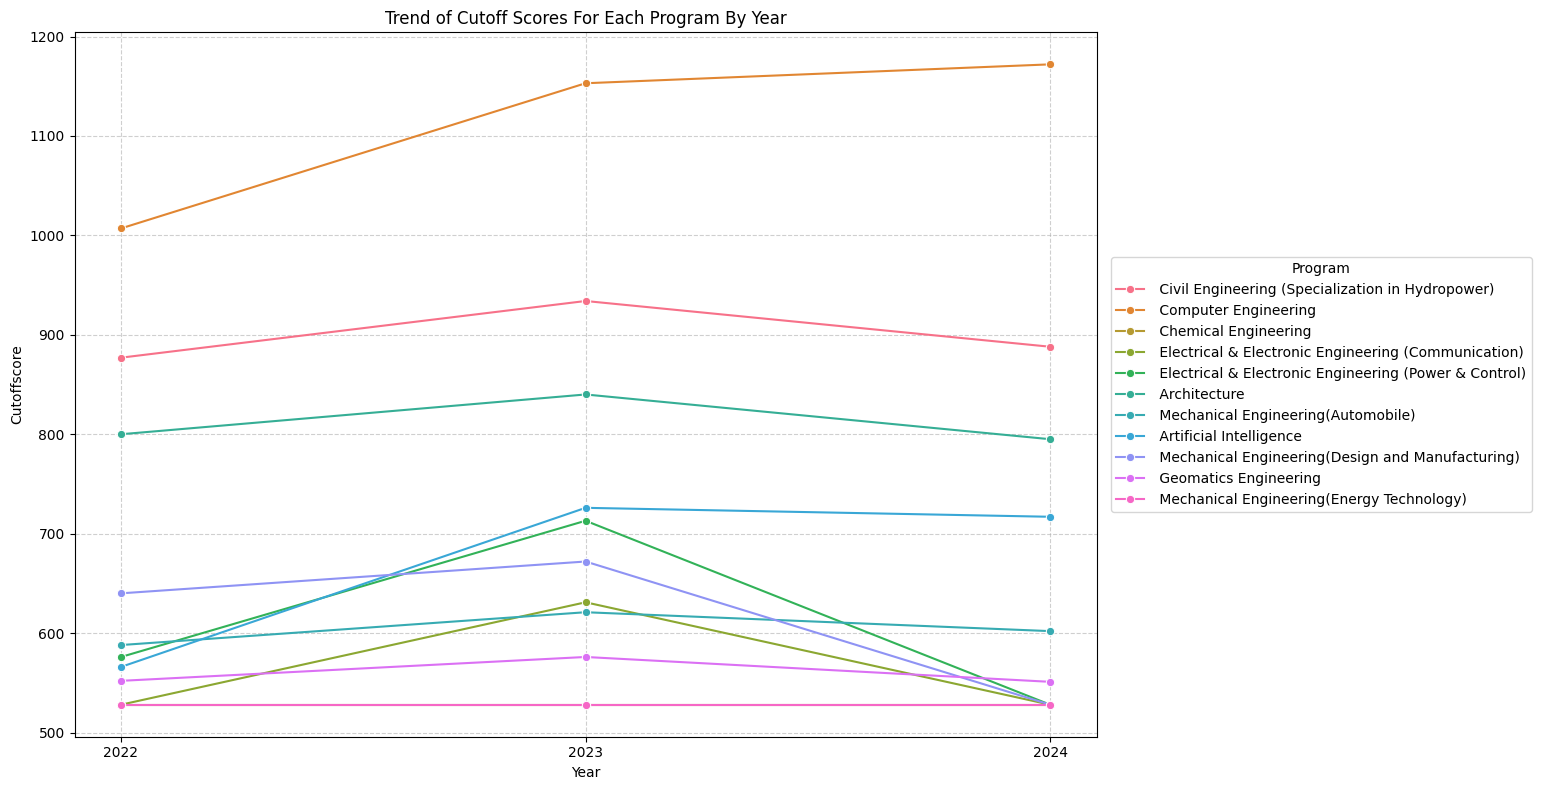

In [7]:
plt.figure(figsize = (16, 8))

ax = sns.lineplot(data = cutoff_plot_data, x = 'Year', y = 'Score', hue = 'Program', marker = 'o')
plt.title('Trend of Cutoff Scores For Each Program By Year')
plt.xticks([2022, 2023, 2024])
plt.xlabel('Year')
plt.ylabel('Cutoffscore')
# plt.ylim(0, max(q90_comp) * 1.2)
plt.legend(title = 'Program', bbox_to_anchor = (1.22,0.5), loc = 'center', fontsize ='medium')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [102]:
#Major preferred by the top 10%

In [106]:
q90_2022['program'].value_counts()

program
BE in Computer Engineering                                     105
BE in Civil Engineering (Specialization in Hydropower)          34
BArch in Architecture                                            6
BE in Mechanical Engineering(Automobile)                         5
BE in Mechanical Engineering(Design and Manufacturing)           4
BTech in Artificial Intelligence                                 4
BE in Electrical & Electronic Engineering (Communication)        3
BE in Geomatics Engineering                                      2
BE in Electrical & Electronic Engineering (Power & Control)      2
BE in Chemical Engineering                                       1
BE in Mechanical Engineering(Energy Technology)                  1
Name: count, dtype: int64

In [107]:
q90_2023['program'].value_counts()

program
BE in Computer Engineering                                     157
BE in Civil Engineering (Specialization in Hydropower)          32
BArch in Architecture                                           10
BE in Mechanical Engineering(Design and Manufacturing)           6
BE in Mechanical Engineering(Automobile)                         5
BTech in Artificial Intelligence                                 5
BE in Electrical & Electronic Engineering (Communication)        5
BE in Mechanical Engineering(Energy Technology)                  3
BE in Electrical & Electronic Engineering (Power & Control)      3
BE in Geomatics Engineering                                      1
BE in Chemical Engineering                                       1
Name: count, dtype: int64

In [108]:
q90_2024['program'].value_counts()

program
BE in Computer Engineering                                     134
BE in Civil Engineering (Specialization in Hydropower)          25
BArch in Architecture                                            4
BE in Geomatics Engineering                                      4
BE in Mechanical Engineering(Automobile)                         3
BE in Electrical & Electronic Engineering (Power & Control)      3
BE in Mechanical Engineering(Design and Manufacturing)           3
BTech in Artificial Intelligence                                 2
BE in Electrical & Electronic Engineering (Communication)        1
BE in Mechanical Engineering(Hydropower)                         1
Name: count, dtype: int64

In [ ]:
#Lets study CE and top percentile scorers.

# We will find the probability of a top percentile scorer choosing CE for each year i.e

# P(CE | 90th percentile) = P (CE and 90th percentile)/ P(90th percentile)

In [159]:
q90_2022_programcount = list(q90_2022.groupby('program').size().reset_index(name = 'count').sort_values(by = 'count', ascending = False)['count'])
q90_2023_programcount = list(q90_2023.groupby('program').size().reset_index(name = 'count').sort_values(by = 'count', ascending = False)['count'])
q90_2024_programcount = list(q90_2024.groupby('program').size().reset_index(name = 'count').sort_values(by = 'count', ascending = False)['count'])

In [121]:
q90_comp_2022 = (q90_2022['program'].str.contains('Computer').sum()) / len(q90_2022)
q90_comp_2023 = (q90_2023['program'].str.contains('Computer').sum()) / len(q90_2023)
q90_comp_2024 = (q90_2024['program'].str.contains('Computer').sum()) / len(q90_2024)
q90_comp = [q90_comp_2022, q90_comp_2023, q90_comp_2024]

In [128]:
q90_comp_plot = pd.DataFrame({
    'Year': [2022, 2023, 2024],
    'Number': q90_comp
})

q90_comp_plot['Percentage'] = q90_comp_plot['Number']*100
q90_comp_plot

,Year,Number,Percentage
0,2022,0.628743,62.874251
1,2023,0.688596,68.859649
2,2024,0.744444,74.444444


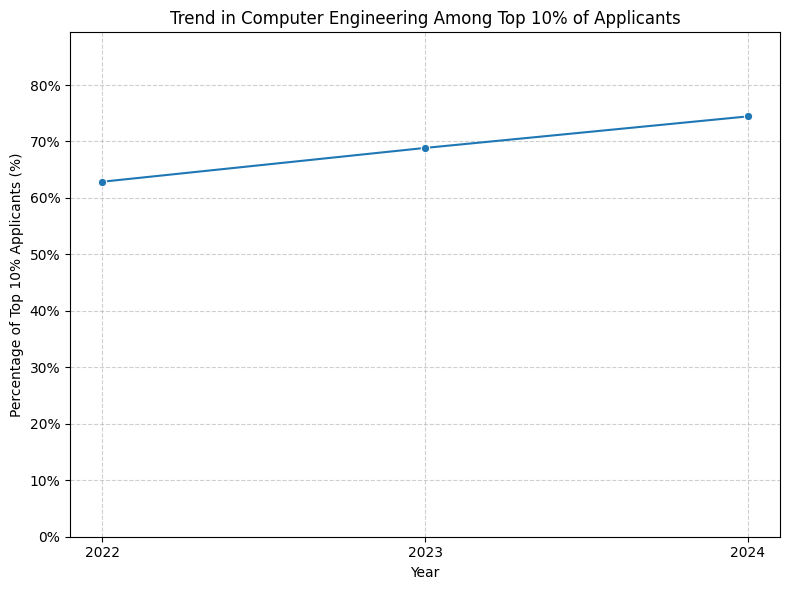

In [4]:
plt.figure(figsize = (8, 6))


ax2 = sns.lineplot(data = q90_comp_plot, x = 'Year', y = 'Number', marker = 'o')
plt.title('Trend in Computer Engineering Among Top 10% of Applicants')
plt.xticks([2022, 2023, 2024])
plt.xlabel('Year')
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.ylabel('Percentage of Top 10% Applicants (%)')
plt.ylim(0, max(q90_comp) * 1.2)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
q90 = pd.concat([q90_2022, q90_2023, q90_2024])
q90 =  q90.drop('first_name', axis = 1)
q90.shape

(575, 6)

In [82]:
((q90.groupby('program').size()).reset_index(name = 'count')).sort_values(by = 'count', ascending = False)

,program,count
3,BE in Computer Engineering,396
2,BE in Civil Engineering (Specialization in Hyd...,91
0,BArch in Architecture,20
7,BE in Mechanical Engineering(Automobile),13
8,BE in Mechanical Engineering(Design and Manufa...,13
11,BTech in Artificial Intelligence,11
4,BE in Electrical & Electronic Engineering (Com...,9
5,BE in Electrical & Electronic Engineering (Pow...,8
6,BE in Geomatics Engineering,7
9,BE in Mechanical Engineering(Energy Technology),4


In [33]:
#Which fields are dominated by women?

In [35]:
df_clean = df.copy()
df_clean.loc[df_clean['program'].str.contains('Mechanical Engineering', na = False), 'program'] = 'BE in Mechanical Engineering'
df_clean.loc[df_clean['program'].str.contains('Electrical & Electronic Engineering', na = False), 'program'] = 'BE in Electrical & Electronic Engineering'
df_clean.program.value_counts()

program
BE in Computer Engineering                                3098
BE in Civil Engineering (Specialization in Hydropower)    1180
BArch in Architecture                                      525
BE in Mechanical Engineering                               276
BE in Geomatics Engineering                                211
BE in Electrical & Electronic Engineering                  209
BTech in Artificial Intelligence                           183
BE in Chemical Engineering                                  19
BE in Mining Engineering                                    11
Name: count, dtype: int64

In [36]:
gender_program = df_clean.groupby(['program', 'gender']).size().unstack(fill_value=0)
gender_program['proportions'] = gender_program['f'] / (gender_program['m'] + gender_program['f'])
gender_program = gender_program.sort_values(by = 'proportions', ascending =  False).copy()
gender_program

gender,f,m,proportions
program,,,
BArch in Architecture,361,164,0.687619
BE in Mining Engineering,6,5,0.545455
BE in Chemical Engineering,9,10,0.473684
BE in Geomatics Engineering,71,140,0.336493
BE in Computer Engineering,760,2338,0.245320
BE in Civil Engineering (Specialization in Hydropower),279,901,0.236441
BTech in Artificial Intelligence,33,150,0.180328
BE in Electrical & Electronic Engineering,35,174,0.167464
BE in Mechanical Engineering,45,231,0.163043


In [37]:
gender_program.index

Index(['BArch in Architecture', 'BE in Mining Engineering',
       'BE in Chemical Engineering', 'BE in Geomatics Engineering',
       'BE in Computer Engineering',
       'BE in Civil Engineering (Specialization in Hydropower)',
       'BTech in Artificial Intelligence',
       'BE in Electrical & Electronic Engineering',
       'BE in Mechanical Engineering'],
      dtype='object', name='program')

In [38]:
program_codes = {
    'BArch in Architecture': 'ARCH',
    'BE in Mining Engineering': 'MIN',
    'BE in Chemical Engineering': 'CHE',
    'BE in Geomatics Engineering': 'GEO',
    'BE in Computer Engineering': 'CE',
    'BE in Mechanical Engineering': 'MECH',
    'BE in Civil Engineering (Specialization in Hydropower)': 'CIEG',
    'BE in Electrical & Electronic Engineering': 'EEEG',
    'BTech in Artificial Intelligence': 'AI'
}
gender_program = gender_program.rename(index = program_codes)

In [39]:
def clean_names(name):
    prefixes = ['BArch in', 'BE in', 'BTech in']
    for prefix in prefixes:
        if name.startswith(prefix):
            return name[len(prefix):]
legend_labels = {name: clean_names(name) for name in program_codes.keys()}
legend_labels

{'BArch in Architecture': ' Architecture',
 'BE in Mining Engineering': ' Mining Engineering',
 'BE in Chemical Engineering': ' Chemical Engineering',
 'BE in Geomatics Engineering': ' Geomatics Engineering',
 'BE in Computer Engineering': ' Computer Engineering',
 'BE in Mechanical Engineering': ' Mechanical Engineering',
 'BE in Civil Engineering (Specialization in Hydropower)': ' Civil Engineering (Specialization in Hydropower)',
 'BE in Electrical & Electronic Engineering': ' Electrical & Electronic Engineering',
 'BTech in Artificial Intelligence': ' Artificial Intelligence'}

In [40]:
gender_program.index

Index(['ARCH', 'MIN', 'CHE', 'GEO', 'CE', 'CIEG', 'AI', 'EEEG', 'MECH'], dtype='object', name='program')

/tmp/ipykernel_30970/2604400973.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x_labels)


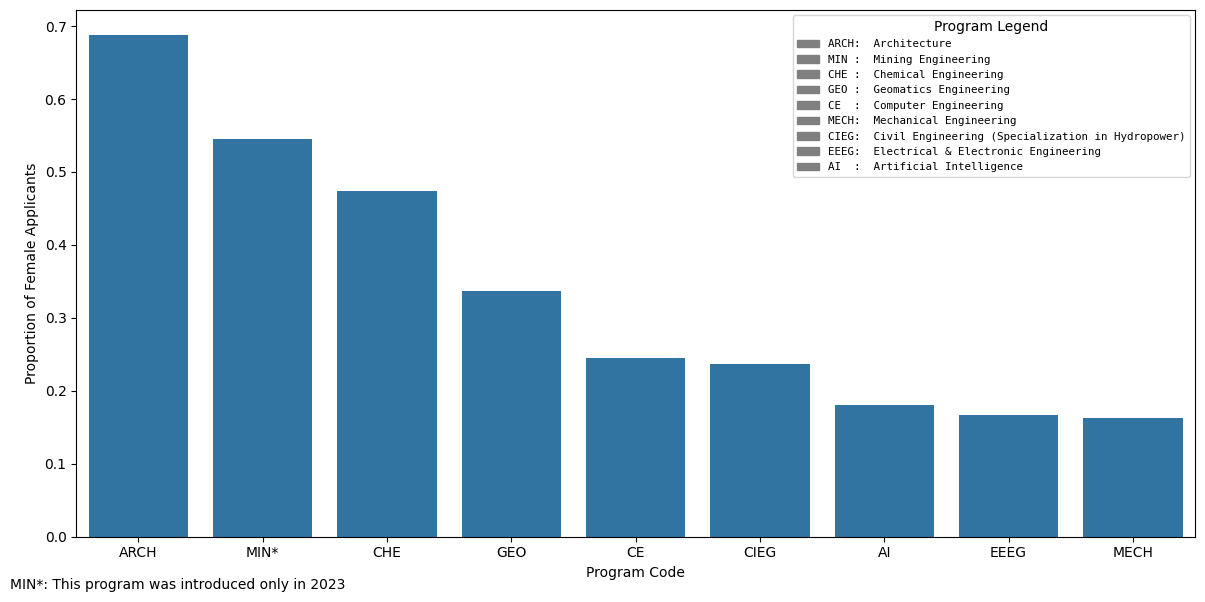

In [42]:
plt.figure(figsize = (12, 6))
ax1 = sns.barplot(x = gender_program.index, y = gender_program['proportions'])
plt.xticks(rotation = 0, ha = 'center')


#Labels
x_labels = []
for element in ax1.get_xticklabels():
    label = element.get_text()
    if label == 'MIN':
        label = 'MIN*'
    x_labels.append(label)
ax1.set_xticklabels(x_labels)
plt.ylabel('Proportion of Female Applicants')
plt.xlabel('Program Code')

#Legends
max_code_length = max(len(code) for code in program_codes.values())
handles = [Patch(color='gray', label=f'{code:<{max_code_length}}: {legend_labels[name]}') for name, code in program_codes.items()]
plt.legend(handles=handles, title='Program Legend', loc='upper right', prop = {'family': 'monospace', 'size':'7.8'})

#Display
plt.figtext(0, 0.01, 'MIN*: This program was introduced only in 2023')
plt.tight_layout()
plt.show()


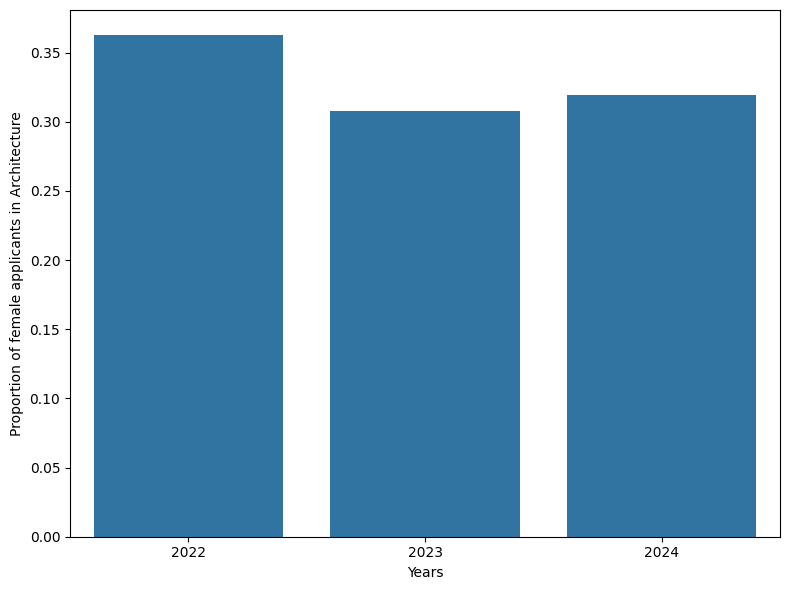

In [43]:
female_arch_2022 = (df_2022['program'] == 'BArch in Architecture').sum() / (df_2022['gender'] == 'f').sum()
female_arch_2023 = (df_2023['program'] == 'BArch in Architecture').sum() / (df_2023['gender'] == 'f').sum()
female_arch_2024 = (df_2024['program'] == 'BArch in Architecture').sum() / (df_2024['gender'] == 'f').sum()

plt.figure(figsize = (8, 6))
ax = sns.barplot(x = ['2022', '2023', '2024'], y = [female_arch_2022, female_arch_2023, female_arch_2024])
plt.xticks(rotation = 0, ha = 'center')
plt.xlabel('Years')
plt.ylabel('Proportion of female applicants in Architecture')
plt.tight_layout()
plt.show()


In [44]:
#Competitive majors in general

In [45]:
(df_2024['program'] == 'BE in Chemical Engineering').sum()

np.int64(0)

In [46]:
program_year_count = df_clean.groupby(['program', 'year']).size().reset_index(name = 'count')
program_year_count

,program,year,count
0,BArch in Architecture,2022,177
1,BArch in Architecture,2023,187
2,BArch in Architecture,2024,161
3,BE in Chemical Engineering,2022,11
4,BE in Chemical Engineering,2023,8
5,BE in Civil Engineering (Specialization in Hyd...,2022,437
6,BE in Civil Engineering (Specialization in Hyd...,2023,456
7,BE in Civil Engineering (Specialization in Hyd...,2024,287
8,BE in Computer Engineering,2022,770
9,BE in Computer Engineering,2023,1248


In [47]:
program_codes = {
    'BArch in Architecture': 'ARCH',
    'BE in Mining Engineering': 'MIN',
    'BE in Chemical Engineering': 'CHE',
    'BE in Geomatics Engineering': 'GEO',
    'BE in Computer Engineering': 'CE',
    'BE in Mechanical Engineering': 'MECH',
    'BE in Civil Engineering (Specialization in Hydropower)': 'CIEG',
    'BE in Electrical & Electronic Engineering': 'EEEG',
    'BTech in Artificial Intelligence': 'AI'
}

def clean_names(name):
    prefixes = ['BArch in', 'BE in', 'BTech in']
    for prefix in prefixes:
        if name.startswith(prefix):
            return name[len(prefix):]
legend_labels = {name: clean_names(name) for name in program_codes.keys()}
legend_labels

{'BArch in Architecture': ' Architecture',
 'BE in Mining Engineering': ' Mining Engineering',
 'BE in Chemical Engineering': ' Chemical Engineering',
 'BE in Geomatics Engineering': ' Geomatics Engineering',
 'BE in Computer Engineering': ' Computer Engineering',
 'BE in Mechanical Engineering': ' Mechanical Engineering',
 'BE in Civil Engineering (Specialization in Hydropower)': ' Civil Engineering (Specialization in Hydropower)',
 'BE in Electrical & Electronic Engineering': ' Electrical & Electronic Engineering',
 'BTech in Artificial Intelligence': ' Artificial Intelligence'}

In [48]:
program_year_count['program_code'] = program_year_count['program'].map(program_codes)
program_year_count

,program,year,count,program_code
0,BArch in Architecture,2022,177,ARCH
1,BArch in Architecture,2023,187,ARCH
2,BArch in Architecture,2024,161,ARCH
3,BE in Chemical Engineering,2022,11,CHE
4,BE in Chemical Engineering,2023,8,CHE
5,BE in Civil Engineering (Specialization in Hyd...,2022,437,CIEG
6,BE in Civil Engineering (Specialization in Hyd...,2023,456,CIEG
7,BE in Civil Engineering (Specialization in Hyd...,2024,287,CIEG
8,BE in Computer Engineering,2022,770,CE
9,BE in Computer Engineering,2023,1248,CE


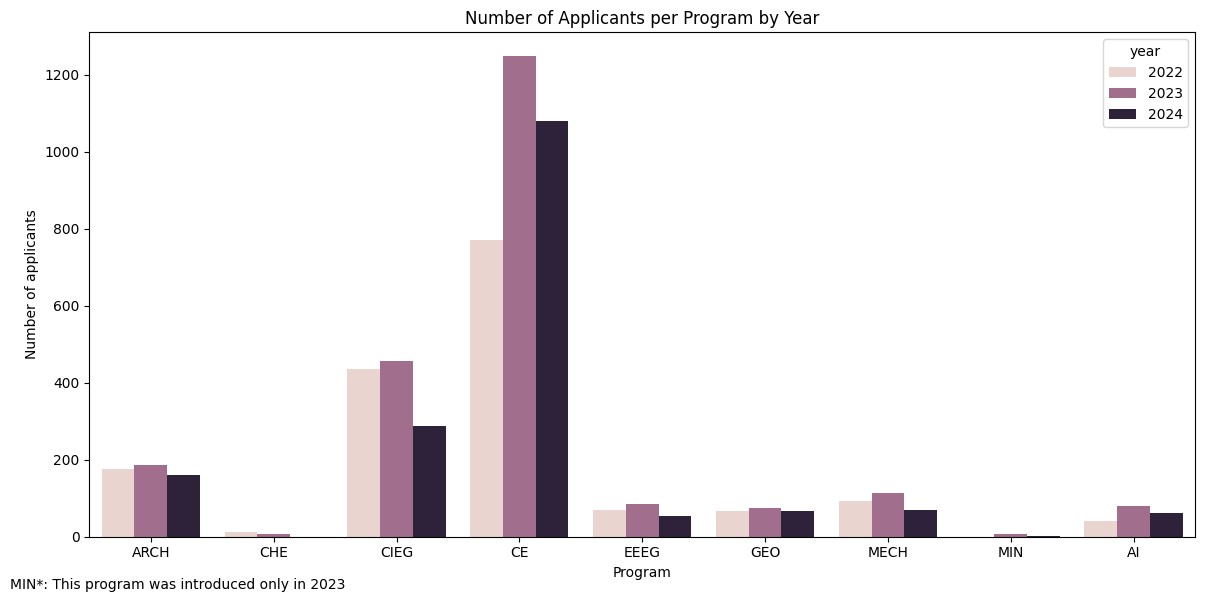

In [50]:
plt.figure(figsize = (12, 6))
ax2 = sns.barplot(data = program_year_count, x = 'program_code', y = 'count', hue = 'year')
plt.xticks(rotation = 0, ha = 'center')


#Labels
plt.xlabel('Program')
plt.ylabel('Number of applicants')
plt.title('Number of Applicants per Program by Year')



#Legends
# max_code_length = max(len(code) for code in program_codes.values())
# handles = [Patch(color='gray', label=f'{code:<{max_code_length}}: {legend_labels[name]}') for name, code in program_codes.items()]
# plt.legend(handles=handles, title='Program Legend', loc='upper left', prop = {'family': 'monospace', 'size':'7.8'})

#Display
plt.figtext(0, 0.01, 'MIN*: This program was introduced only in 2023')
plt.tight_layout()
plt.show()
